In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

import sklearn
from sklearn.model_selection import train_test_split

import hamiltorch
from hamiltorch.util import flatten, unflatten

print("Library Versions:")
print('numpy:',np.__version__)
print('pandas:',pd.__version__)
print('torch:',torch.__version__)
print('sklearn:',sklearn.__version__)
print(torch.cuda.is_available())          # Should print: True
print(torch.cuda.get_device_name(0))      # Should print: your GPU model

Library Versions:
numpy: 1.23.5
pandas: 2.3.2
torch: 2.8.0+cu128
sklearn: 1.7.2
True
NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# 0) Check for CUDA
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import pandas as pd
import numpy as np

# Read the dataset
rov = pd.read_csv(
    '/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/csv_files/X_Data/Tank_data/defender_data_x_run_1_only_mocap_data_savgol.csv',
    sep="\t"
)

# Drop non-dynamics columns
rov = rov.drop(columns=["time", "norm_dof", "norm_value"], errors="ignore")

# Drop the first 3 rows
rov = rov.iloc[3:].reset_index(drop=True)

# Define epsilon threshold
epsilon = 1e-4

# Apply cleaning only to numeric columns
numeric_cols = rov.select_dtypes(include=[np.number]).columns

# Zero out small values and round the rest
rov[numeric_cols] = rov[numeric_cols].applymap(
    lambda x: 0.0 if abs(x) < epsilon else round(x, 5)
)

# Print cleaned result
print("Cleaned shape:", rov.shape)
print("First few rows:\n", rov.head())


Cleaned shape: (38629, 24)
First few rows:
      u_dot    v_dot    w_dot    p_dot    q_dot    r_dot        u        v  \
0  0.03961 -0.13705 -0.19931  0.78873 -0.15177  0.26331 -0.02312  0.03283   
1  0.03542 -0.12491 -0.18339  0.72301 -0.13467  0.23746 -0.02275  0.03156   
2  0.03328 -0.11971 -0.17745  0.69679 -0.12542  0.22512 -0.02241  0.03034   
3  0.03068 -0.11263 -0.16860  0.65913 -0.11441  0.20949 -0.02209  0.02916   
4  0.01936 -0.07257 -0.10970  0.42685 -0.07130  0.13345 -0.02178  0.02803   

         w        p  ...        z      phi    theta      psi    X    Y    Z  \
0  0.02399 -0.04716  ... -1.61604 -0.01791 -0.04980 -2.38211  0.0  0.0  0.0   
1  0.02213 -0.03982  ... -1.61570 -0.01631 -0.05106 -2.38420  0.0  0.0  0.0   
2  0.02033 -0.03272  ... -1.61549 -0.01663 -0.05123 -2.38478  0.0  0.0  0.0   
3  0.01858 -0.02586  ... -1.61528 -0.01674 -0.05148 -2.38534  0.0  0.0  0.0   
4  0.01688 -0.01923  ... -1.61511 -0.01689 -0.05189 -2.38578  0.0  0.0  0.0   

     K    M    N  

/tmp/ipykernel_10162/3997550897.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rov[numeric_cols] = rov[numeric_cols].applymap(


In [20]:

#### ====== MASTER CSV CLEANER SCRIPT ======== ####


rov_train_np, rov_test_np = shape_defender_data(
    rov,
    drop_dvl=True,
    drop_all_nans=True,
    active_dofs=["Z"]     # or "Z" -> but use ["Z"] to match list-based logic
)

def shape_defender_data(
    rov,
    drop_dvl=True,
    drop_all_nans=True,
    active_dofs="Z",    # e.g., ["X", "Y", "Z"] or ["Z"]
    test_size=0.25,
    random_state=42
):
    """
    Shapes Defender CSV data for ML training.

    Parameters
    ----------
    rov : DataFrame
        Cleaned raw dataframe.
    drop_dvl : bool
        Drop rows where DVL (u, v, w) is NaN.
    drop_all_nans : bool
        Drop rows with NaNs in ANY ν, ν̇, or η variable.
    active_dofs : list[str]
        Optional list of DOFs to keep non-zero.
        Examples: ["X"], ["Z"], ["X", "Z"], etc.
    """

    # ----------------------------------------------------------
    # 1. Drop DVL-missing rows
    # ----------------------------------------------------------
    if drop_dvl:
        required_dvl_cols = ["u", "v", "w"]
        rov = rov.dropna(subset=required_dvl_cols)
        print("After DVL drop:", rov.shape)

    # ----------------------------------------------------------
    # 2. Drop rows where ANY ν̇, ν, η contains NaNs
    # ----------------------------------------------------------
    if drop_all_nans:
        # Columns containing the physical state data
        state_cols = [col for col in rov.columns if col not in ["time"]]

        rov = rov.dropna(subset=state_cols)
        print("After full-state NaN drop:", rov.shape)

    # ----------------------------------------------------------
    # 3. Zero out non-active DOFs
    # ----------------------------------------------------------
    if active_dofs is not None:
        # DOF → column mapping
        dof_map = {
            "X": ["u", "u_dot"],
            "Y": ["v", "v_dot"],
            "Z": ["w", "w_dot"],
            "K": ["p", "p_dot"],
            "M": ["q", "q_dot"],
            "N": ["r", "r_dot"],
        }

        # all possible DOFs
        all_dofs = list(dof_map.keys())

        # determine DOFs to zero out
        inactive_dofs = [d for d in all_dofs if d not in active_dofs]

        for d in inactive_dofs:
            for col in dof_map[d]:
                if col in rov.columns:
                    rov[col] = 0.0

        print(f"Zeroed DOFs (inactive): {inactive_dofs}")

    # ----------------------------------------------------------
    # 4. Drop time & convert to NumPy
    # ----------------------------------------------------------
    if "time" in rov.columns:
        rov_numeric = rov.drop(columns=["time"])
    else:
        rov_numeric = rov.copy()

    # Convert to numpy
    rov_np = rov_numeric.to_numpy(dtype=float)

    # ----------------------------------------------------------
    # 5. Train/test split
    # ----------------------------------------------------------
    rov_train_np, rov_test_np = train_test_split(
        rov_np, test_size=test_size, random_state=random_state
    )

    return rov_train_np, rov_test_np


After DVL drop: (12392, 25)
After full-state NaN drop: (12392, 25)
Zeroed DOFs (inactive): ['X', 'Y', 'K', 'M', 'N']


In [4]:
rov_train, rov_test = train_test_split(rov,test_size=0.25,random_state=42) # Splits the dataset into training and test sets setting the random seed to 42 for reproducibility



In [5]:
rov_train_np=rov_train.to_numpy(dtype=np.float32) # Converts the training set to a numpy array
rov_test_np=rov_test.to_numpy(dtype=np.float32) # Converts the test set to a numpy array

In [6]:
# === Full input data ===
x_train_np = rov_train_np[:, :18]
y_train_np = rov_train_np[:, 18:24]

x_test_np = rov_test_np[:, :18]
y_test_np = rov_test_np[:, 18:24]

# === Split x into [nu_dot, nu, eta] ===
nu_dot_train = x_train_np[:, 0:6]
nu_train     = x_train_np[:, 6:12]
eta_train    = x_train_np[:, 12:18]

nu_dot_test = x_test_np[:, 0:6]
nu_test     = x_test_np[:, 6:12]
eta_test    = x_test_np[:, 12:18]


In [7]:
# Convert to PyTorch tensors
nu_dot_train = torch.tensor(nu_dot_train, dtype=torch.float32)
nu_train     = torch.tensor(nu_train,     dtype=torch.float32)
eta_train    = torch.tensor(eta_train,    dtype=torch.float32)
y_train      = torch.tensor(y_train_np,   dtype=torch.float32)

nu_dot_test = torch.tensor(nu_dot_test, dtype=torch.float32)
nu_test     = torch.tensor(nu_test,     dtype=torch.float32)
eta_test    = torch.tensor(eta_test,    dtype=torch.float32)
y_test      = torch.tensor(y_test_np,   dtype=torch.float32)


## CUDA THE DATA 

In [8]:
nu_dot_train = nu_dot_train.to(device)
nu_train     = nu_train.to(device)
eta_train    = eta_train.to(device)
y_train      = y_train.to(device)

nu_dot_test  = nu_dot_test.to(device)
nu_test      = nu_test.to(device)
eta_test     = eta_test.to(device)
y_test       = y_test.to(device)


In [9]:
class ROVDynamicsModel(nn.Module):
    """
    Your existing dynamics node, regenerated with component flags added.

    Flags:
      - use_Crb: include rigid-body Coriolis/centripetal matrix C_RB(nu)
      - use_Ca : include added-mass Coriolis matrix C_A(nu)  (Munk-moment source)
      - use_D  : include damping D(nu)
      - use_g  : include restoring forces g(eta)

    Default: use_Ca=False (stable if you don't model off-diagonal damping).
    """

    def __init__(
        self,
        use_Crb: bool = True,
        use_Ca: bool = True,
        use_D: bool = True,
        use_g: bool = True,
    ):
        super().__init__()

        # -----------------------------
        # Component toggles
        # -----------------------------
        self.use_Crb = use_Crb
        self.use_Ca  = use_Ca
        self.use_D   = use_D
        self.use_g   = use_g

        # === (1) Added-Mass Coefficients (must be negative) ===
        self.X_dot_u = nn.Parameter(torch.tensor(-18.0))
        self.Y_dot_v = nn.Parameter(torch.tensor(-22.0))
        self.Z_dot_w = nn.Parameter(torch.tensor(-22.0))
        self.K_dot_p = nn.Parameter(torch.tensor(-0.079))
        self.M_dot_q = nn.Parameter(torch.tensor(-0.26))
        self.N_dot_r = nn.Parameter(torch.tensor(-0.286))

        # === (2) Rigid-Body Moments of Inertia ===
        self.I_xx = nn.Parameter(torch.tensor(1.0))
        self.I_yy = nn.Parameter(torch.tensor(1.0))
        self.I_zz = nn.Parameter(torch.tensor(1.0))

        # === (3) Center of Gravity Offsets ===
        self.x_g = nn.Parameter(torch.tensor(0.0))
        self.y_g = nn.Parameter(torch.tensor(0.0))
        self.z_g = nn.Parameter(torch.tensor(0.0))

        # === (4) Linear Damping Coefficients (must be negative) ===
        self.X_u = nn.Parameter(torch.tensor(-4.66))
        self.Y_v = nn.Parameter(torch.tensor(-12.6))
        self.Z_w = nn.Parameter(torch.tensor(-14.17))
        self.K_p = nn.Parameter(torch.tensor(-1.5))
        self.M_q = nn.Parameter(torch.tensor(-2.9))
        self.N_r = nn.Parameter(torch.tensor(-10.343))

        # === (5) Quadratic Damping Coefficients (must be negative) ===
        self.X_uu = nn.Parameter(torch.tensor(-51.5))
        self.Y_vv = nn.Parameter(torch.tensor(-102.006))
        self.Z_ww = nn.Parameter(torch.tensor(-155.8358))
        self.K_pp = nn.Parameter(torch.tensor(-2.1))
        self.M_qq = nn.Parameter(torch.tensor(-14.6))
        self.N_rr = nn.Parameter(torch.tensor(-8.8))

        # === (6) Restoring Force / Buoyancy Parameters ===
        self.B   = nn.Parameter(torch.tensor(17.2 * 9.8))  # ~169 N
        self.z_b = nn.Parameter(torch.tensor(-0.05))

        # === (7) Constant Physical Mass (non-learnable) ===
        self.m_val = 17.2  # [kg], fixed vehicle mass

        # Debug storage (optional)
        self.Crb = None
        self.Ca  = None
        self.C   = None
        self.D   = None

    # ---------------------------------------------------------------------
    # MASS MATRIX
    # ---------------------------------------------------------------------
    def build_mass_matrix(self):
        """
        Build the full 6×6 mass matrix M = M_RB + M_A (Fossen Eq. 3.49).
        Uses NED convention (z down).
        Fully differentiable (no torch.tensor() breaks).
        """
        Ma = -1.0 * torch.diag(torch.stack([
            self.X_dot_u, self.Y_dot_v, self.Z_dot_w,
            self.K_dot_p, self.M_dot_q, self.N_dot_r
        ]))

        m  = torch.as_tensor(self.m_val, dtype=torch.float32, device=Ma.device)
        xg = self.x_g
        yg = self.y_g
        zg = self.z_g

        Mrb = torch.zeros((6, 6), dtype=torch.float32, device=Ma.device)

        Mrb[0, 0] = m
        Mrb[1, 1] = m
        Mrb[2, 2] = m
        Mrb[0, 4] =  m * zg
        Mrb[0, 5] = -m * yg
        Mrb[1, 3] = -m * zg
        Mrb[1, 5] =  m * xg
        Mrb[2, 3] =  m * yg
        Mrb[2, 4] = -m * xg
        Mrb[3, 1] = -m * zg
        Mrb[3, 2] =  m * yg
        Mrb[3, 3] = self.I_xx
        Mrb[4, 0] =  m * zg
        Mrb[4, 2] = -m * xg
        Mrb[4, 4] = self.I_yy
        Mrb[5, 0] = -m * yg
        Mrb[5, 1] =  m * xg
        Mrb[5, 5] = self.I_zz

        return Mrb + Ma

    # ---------------------------------------------------------------------
    # CORIOLIS (Crb + optional Ca)
    # ---------------------------------------------------------------------
    def build_coriolis(self, nu):
        """
        Build C_total(nu) = (use_Crb)*C_RB(nu) + (use_Ca)*C_A(nu)

        nu: (batch,6)
        returns: (batch,6,6)
        """
        u, v, w, p, q, r = [nu[:, i] for i in range(6)]
        B = nu.shape[0]

        m = torch.as_tensor(self.m_val, dtype=torch.float32, device=nu.device)
        Ixx, Iyy, Izz = self.I_xx, self.I_yy, self.I_zz

        xg = self.x_g
        yg = self.y_g
        zg = self.z_g

        # === Build C_RB (rigid-body) ===
        Crb = torch.zeros((B, 6, 6), dtype=torch.float32, device=nu.device)

        Crb[:, 0, 0] = 0.0
        Crb[:, 0, 1] = -m * r
        Crb[:, 0, 2] =  m * q
        Crb[:, 0, 3] =  m * (q * yg + r * zg)
        Crb[:, 0, 4] = -m * (q * xg)
        Crb[:, 0, 5] = -m * (r * xg)

        Crb[:, 1, 0] =  m * r
        Crb[:, 1, 1] = 0.0
        Crb[:, 1, 2] = -m * p
        Crb[:, 1, 3] = -m * (p * yg)
        Crb[:, 1, 4] =  m * (p * xg + r * zg)
        Crb[:, 1, 5] = -m * (r * yg)

        Crb[:, 2, 0] = -m * q
        Crb[:, 2, 1] =  m * p
        Crb[:, 2, 2] = 0.0
        Crb[:, 2, 3] = -m * (p * zg)
        Crb[:, 2, 4] = -m * (q * zg)
        Crb[:, 2, 5] =  m * (p * xg + q * yg)

        Crb[:, 3, 0] = -m * (q * yg + r * zg)
        Crb[:, 3, 1] =  m * (p * yg)
        Crb[:, 3, 2] =  m * (p * zg)
        Crb[:, 3, 3] = 0.0
        Crb[:, 3, 4] =  Izz * r
        Crb[:, 3, 5] = -Iyy * q

        Crb[:, 4, 0] =  m * (q * xg)
        Crb[:, 4, 1] = -m * (p * xg + r * zg)
        Crb[:, 4, 2] =  m * (q * zg)
        Crb[:, 4, 3] = -Izz * r
        Crb[:, 4, 4] = 0.0
        Crb[:, 4, 5] =  Ixx * p

        Crb[:, 5, 0] =  m * (r * xg)
        Crb[:, 5, 1] =  m * (r * yg)
        Crb[:, 5, 2] = -m * (p * xg + q * yg)
        Crb[:, 5, 3] =  Iyy * q
        Crb[:, 5, 4] = -Ixx * p
        Crb[:, 5, 5] = 0.0

        # === Build C_A (added-mass) ===
        Ca = torch.zeros_like(Crb)
        if self.use_Ca:
            a1 = self.X_dot_u * u
            a2 = self.Y_dot_v * v
            a3 = self.Z_dot_w * w
            b1 = self.K_dot_p * p
            b2 = self.M_dot_q * q
            b3 = self.N_dot_r * r

            Ca[:, 0, 4] = -a3
            Ca[:, 0, 5] =  a2
            Ca[:, 1, 3] =  a3
            Ca[:, 1, 5] = -a1
            Ca[:, 2, 3] = -a2
            Ca[:, 2, 4] =  a1

            Ca[:, 3, 1] = -a3
            Ca[:, 3, 2] =  a2
            Ca[:, 3, 4] = -b3
            Ca[:, 3, 5] =  b2

            Ca[:, 4, 0] =  a3
            Ca[:, 4, 2] = -a1
            Ca[:, 4, 3] =  b3
            Ca[:, 4, 5] = -b1

            Ca[:, 5, 0] = -a2
            Ca[:, 5, 1] =  a1
            Ca[:, 5, 3] = -b2
            Ca[:, 5, 4] =  b1

        # === Total Coriolis with flags ===
        C_total = torch.zeros_like(Crb)
        if self.use_Crb:
            C_total = C_total + Crb
        if self.use_Ca:
            C_total = C_total + Ca

        self.Crb = Crb
        self.Ca  = Ca
        self.C   = C_total
        return C_total

    # ---------------------------------------------------------------------
    # DAMPING
    # ---------------------------------------------------------------------
    def build_damping(self, nu):
        """
        Damping matrix D(ν) with negative coefficients AND a leading -1.

            diag_entries = lin + quad*|nu|
            D = -diag(diag_entries)

        Coefficients expected to be NEGATIVE values.
        """
        lin_params = torch.stack([
            self.X_u, self.Y_v, self.Z_w,
            self.K_p, self.M_q, self.N_r
        ])

        quad_params = torch.stack([
            self.X_uu, self.Y_vv, self.Z_ww,
            self.K_pp, self.M_qq, self.N_rr
        ])

        diag_entries = lin_params.unsqueeze(0) + quad_params.unsqueeze(0) * torch.abs(nu)
        D = -1.0 * torch.diag_embed(diag_entries)

        self.D = D
        return D

    # ---------------------------------------------------------------------
    # RESTORING FORCE
    # ---------------------------------------------------------------------
    def build_restoring_force(self, eta):
        """
        Fossen Eq. (3.77) restoring forces in NED.
        eta: (batch,6) [x,y,z,phi,theta,psi]
        """
        phi = eta[:, 3]
        theta = eta[:, 4]

        g = 9.8
        m = torch.as_tensor(self.m_val, dtype=torch.float32, device=eta.device)
        W = m * g
        B = self.B.to(dtype=torch.float32, device=eta.device)

        x_G, y_G, z_G = self.x_g, self.y_g, self.z_g
        x_B = torch.zeros(1, device=eta.device)
        y_B = torch.zeros(1, device=eta.device)
        z_B = self.z_b.to(dtype=torch.float32, device=eta.device)

        WB    = W - B
        xW_xB = x_G * W - x_B * B
        yW_yB = y_G * W - y_B * B
        zW_zB = z_G * W - z_B * B

        tau_g = torch.stack([
            WB * torch.sin(theta),
            -WB * torch.cos(theta) * torch.sin(phi),
            -WB * torch.cos(theta) * torch.cos(phi),
            -yW_yB * torch.cos(theta) * torch.cos(phi) + zW_zB * torch.cos(theta) * torch.sin(phi),
            zW_zB * torch.sin(theta) + xW_xB * torch.cos(theta) * torch.cos(phi),
            -xW_xB * torch.cos(theta) * torch.sin(phi) - yW_yB * torch.sin(theta)
        ], dim=1)

        return tau_g

    # ---------------------------------------------------------------------
    # FORWARD
    # ---------------------------------------------------------------------
    def forward(self, nu_dot, nu, eta):
        # === Mass force: M * nu_dot ===
        M = self.build_mass_matrix()                  # (6,6)
        tau_M = torch.matmul(nu_dot, M.T)             # (batch,6)

        # === Coriolis force: C(nu) * nu ===
        C = self.build_coriolis(nu)                   # (batch,6,6)
        tau_C = torch.einsum("bij,bj->bi", C, nu)     # (batch,6)

        # === Damping force ===
        if self.use_D:
            D = self.build_damping(nu)                # (batch,6,6)
            tau_D = torch.einsum("bij,bj->bi", D, nu)
        else:
            tau_D = torch.zeros_like(tau_M)

        # === Restoring force ===
        if self.use_g:
            tau_g = self.build_restoring_force(eta)   # (batch,6)
        else:
            tau_g = torch.zeros_like(tau_M)

        # === Total wrench ===
        tau = tau_M + tau_C + tau_D + tau_g
        return tau


In [10]:
prior_means = {
    "X_dot_u": torch.tensor(-18.0),
    "Y_dot_v": torch.tensor(-22.58),
    "Z_dot_w": torch.tensor(-22.3775),
    "K_dot_p": torch.tensor(-0.079),
    "M_dot_q": torch.tensor(-0.26),
    "N_dot_r": torch.tensor(-0.286),

    "I_xx": torch.tensor(1.0),
    "I_yy": torch.tensor(1.0),
    "I_zz": torch.tensor(1.0),

    "x_g": torch.tensor(0.0),
    "y_g": torch.tensor(0.0),
    "z_g": torch.tensor(0.0),

    "X_u": torch.tensor(-4.6),
    "Y_v": torch.tensor(-8.25),
    "Z_w": torch.tensor(-14.17),
    "K_p": torch.tensor(-1.5),
    "M_q": torch.tensor(-2.9),
    "N_r": torch.tensor(-10.343),

    "X_uu": torch.tensor(-51.8358),
    "Y_vv": torch.tensor(-102.01),
    "Z_ww": torch.tensor(-155.84),
    "K_pp": torch.tensor(-2.1),
    "M_qq": torch.tensor(-14.6),
    "N_rr": torch.tensor(-8.8),

    "B": torch.tensor(168.56),
    "z_b": torch.tensor(-0.05)
}

selected_L1 = []  # (unless you add cross-couplings to test)

selected_L2 = [
    # Inertias
    "I_xx", "I_yy", "I_zz",
    # Added mass (diagonal)
    "X_dot_u", "Y_dot_v", "Z_dot_w", "K_dot_p", "M_dot_q", "N_dot_r",
    # Linear damping (diagonal)
    "X_u", "Y_v", "Z_w", "K_p", "M_q", "N_r",
    # Quadratic damping (diagonal)
    "X_uu", "Y_vv", "Z_ww", "K_pp", "M_qq", "N_rr",
    # Hydrostatics / geometry
    "B", "z_b", "x_g", "y_g", "z_g"
]


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# 3) FLATTEN INITIAL PARAMETERS
# ──────────────────────────────────────────────────────────────────────────────
model = ROVDynamicsModel().to(device)
params_init = flatten(model).clone().detach()  # (P,)
print("params_init.shape:", params_init.shape)

# ──────────────────────────────────────────────────────────────────────────────
# 4) HMC HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────────────
step_size   = 1e-3     # try around 1e-3 … 5e-3
num_samples = 3000      # number of posterior draws to keep
burn        = 100       # number of initial draws to discard
L           = 20       # leapfrog steps per sample
l2_coeff    = 50.0     # L2 regularization coefficient for the prior
l1_coeff    = 0.0     # L1 regularization coefficient for the prior

# ──────────────────────────────────────────────────────────────────────────────
# 5) LIKELIHOOD NOISE (per-DOF)
# ──────────────────────────────────────────────────────────────────────────────

# [X, Y, Z, K, M, N]  →  [N, N, N, N·m, N·m, N·m]
# X channel noise (pick based on typical residual scale in X)
sigma_N = 1.0

# "Ignore" the other channels by making sigma enormous
BIG_N   = 1e6   # for forces [N]
BIG_Nm  = 1e6   # for moments [N·m] (same idea)

sigma_noise = torch.tensor(
    [BIG_N, BIG_N, BIG_N, BIG_Nm, BIG_Nm, sigma_N],
    dtype=torch.float32,
    device=device
)


# ──────────────────────────────────────────────────────────────────────────────
# 6) GAUSSIAN PRIOR COEFFICIENT
# ──────────────────────────────────────────────────────────────────────────────
#prior_coeff = 1.0  # if you want no prior, set this to 0.0

params_init.shape: torch.Size([26])


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# 7) NEGATIVE LOG‐LIKELIHOOD HELPER
# ──────────────────────────────────────────────────────────────────────────────
def nll_tau(tau_true: torch.Tensor, tau_pred: torch.Tensor, std) -> torch.Tensor:
    """
    tau_true, tau_pred: (N,6)
    std: either scalar float, or tensor shape (6,) or (1,6) or (N,6)
    returns: (N,6) elementwise Gaussian NLL (up to constant)
    """
    if not torch.is_tensor(std):
        std_t = torch.full((1,), float(std), dtype=tau_pred.dtype, device=tau_pred.device)
    else:
        std_t = std.to(dtype=tau_pred.dtype, device=tau_pred.device).detach()

    # reshape for broadcasting if std is (6,)
    if std_t.ndim == 1 and std_t.numel() == tau_pred.shape[1]:
        std_t = std_t.view(1, -1)  # (1,6)

    resid = tau_true - tau_pred
    return 0.5 * (resid / std_t).pow(2) + torch.log(std_t)


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# 8) CUSTOM log_prob_func (with L1 + L2 penalties, all terms on GPU) USE THIS ONE
# ──────────────────────────────────────────────────────────────────────────────
def log_prob_func(params_flat: torch.Tensor) -> torch.Tensor:
    """
    1) Unflatten params_flat → model.parameters()
    2) Forward pass: model(nu_dot_train, nu_train, eta_train) → (N,6)
    3) Compute nll_matrix = nll_tau(y_train, tau_pred, sigma_noise) → (N,6)
    4) Sum over N×6 to get scalar nll
    5) Compute L2 penalty over selected_L2 around prior_means
    6) Compute L1 penalty over selected_L1
    7) Return log_posterior = -nll - l2_coeff * L2 - l1_coeff * L1 - dummy_term
    """
    # 8.1) Unpack parameters into model
    unflatten(model, params_flat)

    # 8.2) Forward pass → predicted tau (N,6)
    tau_pred = model(nu_dot_train, nu_train, eta_train)

    # 8.3) Element‐wise NLL (N,6)
    nll_matrix = nll_tau(y_train, tau_pred, sigma_noise)

    # 8.4) Sum to scalar
    nll = nll_matrix.sum()

    # 8.5) L2 penalty over “selected_L2” parameters around their prior_means
    l2_term = torch.tensor(0.0, device=params_flat.device)
    if l2_coeff > 0.0:
        for name, param in model.named_parameters():
            if name in selected_L2:
                mu = prior_means[name].to(param.device)
                l2_term = l2_term + torch.sum((param - mu) ** 2)

    # 8.6) L1 penalty over “selected_L1” parameters (encourage closeness to zero)
    l1_term = torch.tensor(0.0, device=params_flat.device)
    if l1_coeff > 0.0:
        for name, param in model.named_parameters():
            if name in selected_L1:
                l1_term = l1_term + torch.sum(torch.abs(param))

    # 8.7) Tiny “dummy” term to force every parameter to appear
    epsilon    = torch.tensor(1e-6, device=params_flat.device)
    dummy_term = epsilon * torch.sum(params_flat)

    # 8.8) Combine everything
    log_posterior = -nll - l2_coeff * l2_term - l1_coeff * l1_term - dummy_term

    return log_posterior


In [14]:
num_params = sum(p.numel() for p in model.parameters())
print("Number of scalar parameters in model:", num_params)


Number of scalar parameters in model: 26


In [42]:
with torch.no_grad():
    unflatten(model, params_init)
    tau_pred = model(nu_dot_train, nu_train, eta_train)
    nll_matrix = nll_tau(y_train, tau_pred, sigma_noise)   # (N,6)

    nll_per_dof = nll_matrix.sum(dim=0)  # (6,)
    print("NLL per DOF:", nll_per_dof.cpu().numpy())
    print("Fraction per DOF:", (nll_per_dof / nll_per_dof.sum()).cpu().numpy())


NLL per DOF: [3.6472949e+04 3.6472949e+04 3.6472949e+04 3.6472949e+04 3.6472949e+04
 3.0985928e+01]
Fraction per DOF: [1.9996604e-01 1.9996604e-01 1.9996604e-01 1.9996604e-01 1.9996604e-01
 1.6988297e-04]


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# 9) RUN HMC
# ──────────────────────────────────────────────────────────────────────────────
hamiltorch.set_random_seed(123)

posterior = hamiltorch.sample(
    log_prob_func=log_prob_func,
    params_init=params_init,
    num_samples=num_samples,
    num_steps_per_sample=L,
    step_size=step_size,
    burn=burn,
    verbose=True, 
    store_on_GPU=True,
)



Sampling (Sampler.HMC; Integrator.IMPLICIT)
Time spent  | Time remain.| Progress             | Samples   | Samples/sec


/home/andrew/.local/lib/python3.10/site-packages/hamiltorch/samplers.py:626: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return float(-h_new + h_old)


0d:00:02:47 | 0d:00:00:00 | #################### | 3000/3000 | 17.90       
Acceptance Rate 1.00


In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# (D) POST‐PROCESS THE RAW “posterior” LIST INTO A (num_samples × 26) TENSOR
# ──────────────────────────────────────────────────────────────────────────────

# 1) Stack into a (num_samples, 26) tensor:
samples_tensor = torch.stack(posterior, dim=0)  # shape = (num_samples, 26)

# 2) Compute per‐parameter mean and std (over the num_samples axis):
post_mean = samples_tensor.mean(dim=0)  # shape = (26,)
post_std  = samples_tensor.std(dim=0)   # shape = (26,)

# 3) Build a name→(mean, std) mapping
param_names = [name for name, _ in model.named_parameters()]
if len(param_names) != samples_tensor.size(1):
    raise RuntimeError(
        f"Expected {len(param_names)} columns in samples_tensor, "
        f"but got shape {samples_tensor.shape}"
    )

param_stats = {
    name: (post_mean[i].item(), post_std[i].item())
    for i, name in enumerate(param_names)
}

# 4) Print them out
print("\nParameter statistics (posterior mean ± posterior std):")
for name, (μ, σ) in param_stats.items():
    print(f"  {name}: {μ:.4f} \u00B1 {σ:.4f}")

save_path = "/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_circle_samples.pt"

torch.save(
    {
        "samples": samples_tensor.detach().cpu(),  # (N, 26)
        "param_names": param_names,                # list[str], length 26
    },
    save_path
)


print(f"Saved HMC samples to: {save_path}")


Parameter statistics (posterior mean ± posterior std):
  X_dot_u: -18.2947 ± 0.2852
  Y_dot_v: -21.0252 ± 0.6136
  Z_dot_w: -21.3708 ± 0.2886
  K_dot_p: -0.8001 ± 0.3702
  M_dot_q: 0.4232 ± 0.3518
  N_dot_r: 0.2228 ± 0.4938
  I_xx: 1.3475 ± 0.8481
  I_yy: 1.4710 ± 0.2861
  I_zz: 0.4989 ± 0.3283
  x_g: -0.6023 ± 0.3229
  y_g: -0.0052 ± 0.2434
  z_g: 1.0259 ± 0.4610
  X_u: -4.5291 ± 0.5062
  Y_v: -11.9706 ± 0.3835
  Z_w: -14.6477 ± 0.3942
  K_p: -0.5803 ± 0.5272
  M_q: -3.4184 ± 0.7228
  N_r: -9.4010 ± 0.5265
  X_uu: -52.4500 ± 0.5196
  Y_vv: -101.6791 ± 0.2917
  Z_ww: -156.8065 ± 0.5748
  K_pp: -3.1714 ± 0.6674
  M_qq: -15.1344 ± 0.3358
  N_rr: -9.9353 ± 0.7349
  B: 168.4828 ± 0.2167
  z_b: 0.5583 ± 0.4088
Saved HMC samples to: /home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_circle_samples.pt


In [17]:
# Convert to NumPy for convenience
samples_np = samples_tensor.cpu().numpy()

print("\nParameter summary with relative uncertainty:")
print(f"{'Parameter':<10} {'Mean':>10} {'Std':>10} {'CV[%]':>10} {'q2.5':>10} {'q97.5':>10}")
print("-" * 65)

for i, name in enumerate(param_names):
    data = samples_np[:, i]
    mean = post_mean[i].item()
    std = post_std[i].item()
    cv = abs(std / mean) * 100 if mean != 0 else np.nan
    q025, q975 = np.percentile(data, [2.5, 97.5])
    print(f"{name:<10} {mean:10.4f} {std:10.4f} {cv:10.1f} {q025:10.3f} {q975:10.3f}")


Parameter summary with relative uncertainty:
Parameter        Mean        Std      CV[%]       q2.5      q97.5
-----------------------------------------------------------------
X_dot_u      -18.2947     0.2852        1.6    -18.762    -17.874
Y_dot_v      -21.0252     0.6136        2.9    -22.017    -20.106
Z_dot_w      -21.3708     0.2886        1.4    -21.889    -20.792
K_dot_p       -0.8001     0.3702       46.3     -1.466     -0.126
M_dot_q        0.4232     0.3518       83.1     -0.233      1.072
N_dot_r        0.2228     0.4938      221.6     -0.462      1.126
I_xx           1.3475     0.8481       62.9      0.030      2.948
I_yy           1.4710     0.2861       19.5      0.938      1.984
I_zz           0.4989     0.3283       65.8     -0.067      1.045
x_g           -0.6023     0.3229       53.6     -1.239     -0.007
y_g           -0.0052     0.2434     4713.0     -0.438      0.468
z_g            1.0259     0.4610       44.9      0.349      1.957
X_u           -4.5291     0.50

In [18]:
# samples_tensor: (S, P)
S = samples_tensor.shape[0]

logp = torch.empty(S, device='cpu')

with torch.no_grad():
    for s in range(S):
        # hamiltorch samples are already on GPU if store_on_GPU=True
        theta = samples_tensor[s].to(device)
        logp[s] = log_prob_func(theta).detach().cpu()

best_idx = torch.argmax(logp).item()
theta_star = samples_tensor[best_idx].detach().clone()

print("Best (MAP-from-samples) index:", best_idx)
print("Best log posterior:", logp[best_idx].item())

unflatten(model, theta_star.to(device))

print("\nMAP-from-samples parameter values:")
for name, p in model.named_parameters():
    print(f"  {name}: {p.item():.6f}")



Best (MAP-from-samples) index: 0
Best log posterior: -111852.234375

MAP-from-samples parameter values:
  X_dot_u: -18.000000
  Y_dot_v: -22.000000
  Z_dot_w: -22.000000
  K_dot_p: -0.079000
  M_dot_q: -0.260000
  N_dot_r: -0.286000
  I_xx: 1.000000
  I_yy: 1.000000
  I_zz: 1.000000
  x_g: 0.000000
  y_g: 0.000000
  z_g: 0.000000
  X_u: -4.660000
  Y_v: -12.600000
  Z_w: -14.170000
  K_p: -1.500000
  M_q: -2.900000
  N_r: -10.343000
  X_uu: -51.500000
  Y_vv: -102.005997
  Z_ww: -155.835800
  K_pp: -2.100000
  M_qq: -14.600000
  N_rr: -8.800000
  B: 168.559998
  z_b: -0.050000


corr(X_u, X_uu) = -0.7735474871180853
corr(X_u, X_dot_u) = -0.4762986424315802


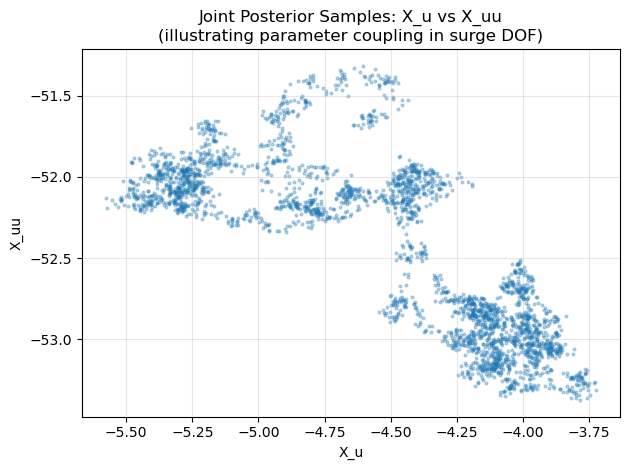

In [19]:

idx = {n:i for i,n in enumerate(param_names)}
xu  = samples_tensor[:, idx['X_u']].cpu().numpy()
xuu = samples_tensor[:, idx['X_uu']].cpu().numpy()
xdu = samples_tensor[:, idx['X_dot_u']].cpu().numpy()

print("corr(X_u, X_uu) =", np.corrcoef(xu, xuu)[0,1])
print("corr(X_u, X_dot_u) =", np.corrcoef(xu, xdu)[0,1])

plt.scatter(xu, xuu, s=4, alpha=0.3)
plt.xlabel("X_u")
plt.ylabel("X_uu")
plt.title("Joint Posterior Samples: X_u vs X_uu\n(illustrating parameter coupling in surge DOF)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


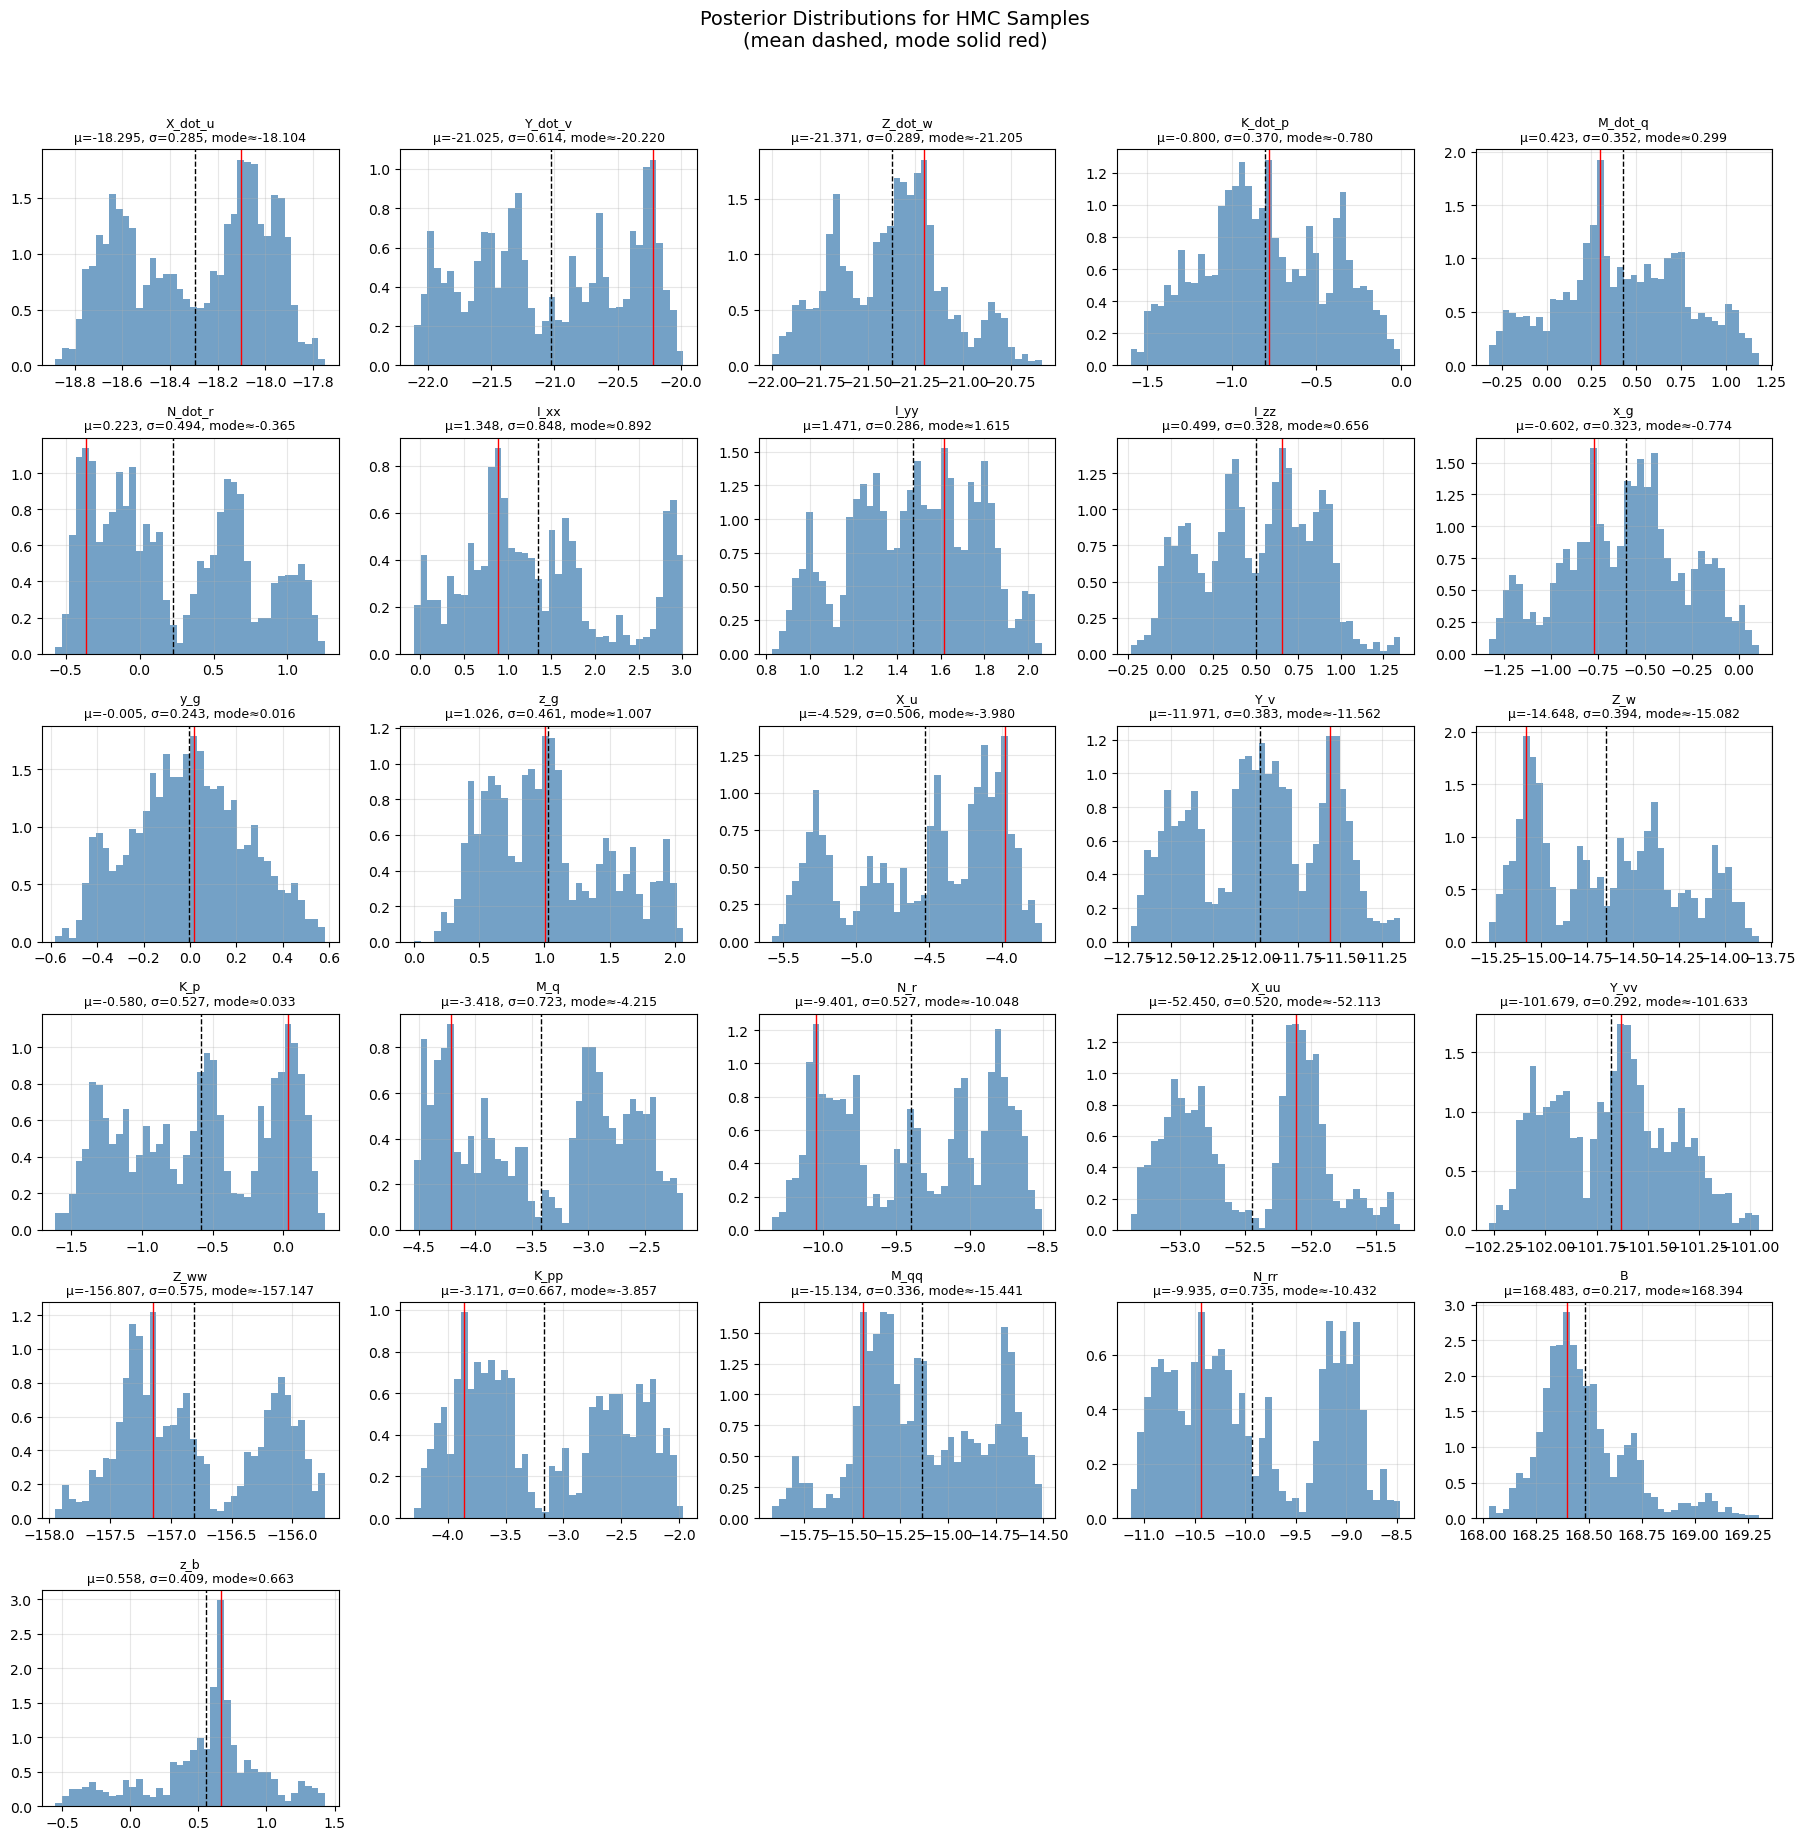

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# 5) Plot posterior histograms for each parameter (mean + mode)
# ──────────────────────────────────────────────────────────────────────────────

num_params = samples_tensor.shape[1]
ncols = 5
nrows = math.ceil(num_params / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()

for i, name in enumerate(param_names):
    ax = axes[i]
    data = samples_tensor[:, i].cpu().numpy()

    # Histogram (get counts + bin edges to compute mode)
    counts, bins, _ = ax.hist(data, bins=40, density=True, color='steelblue', alpha=0.75)

    # Mean and Std from earlier
    m = post_mean[i].item()
    s = post_std[i].item()

    # Mode = midpoint of highest histogram bin
    mode_idx = np.argmax(counts)
    mode_val = 0.5 * (bins[mode_idx] + bins[mode_idx + 1])

    # Draw vertical lines
    ax.axvline(m, color='k', linestyle='--', linewidth=1, label='mean')
    ax.axvline(mode_val, color='r', linestyle='-', linewidth=1, label='mode')

    # Title with μ, σ, and mode
    ax.set_title(f"{name}\nμ={m:.3f}, σ={s:.3f}, mode≈{mode_val:.3f}", fontsize=9)
    ax.grid(alpha=0.3)

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Posterior Distributions for HMC Samples\n(mean dashed, mode solid red)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

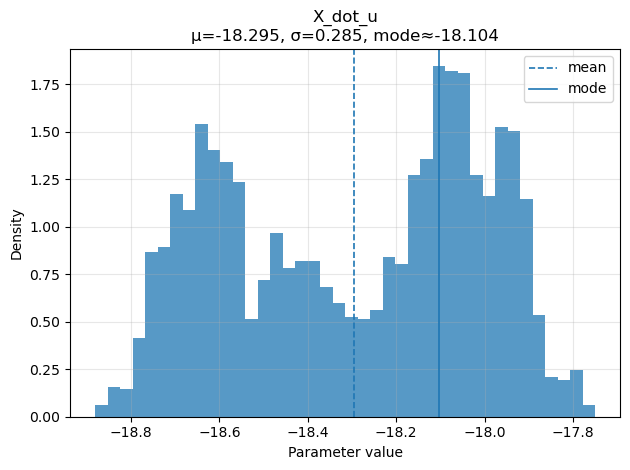

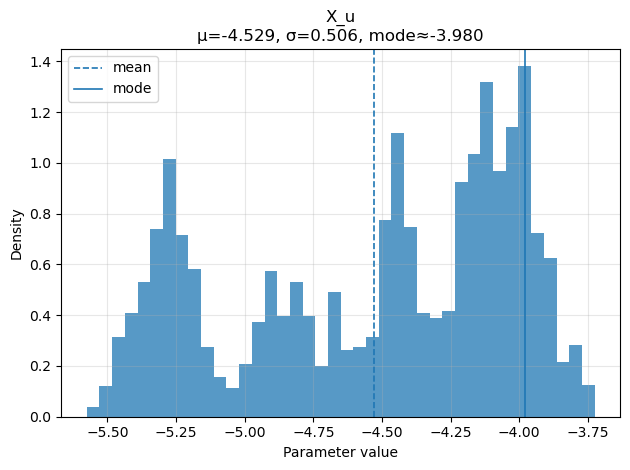

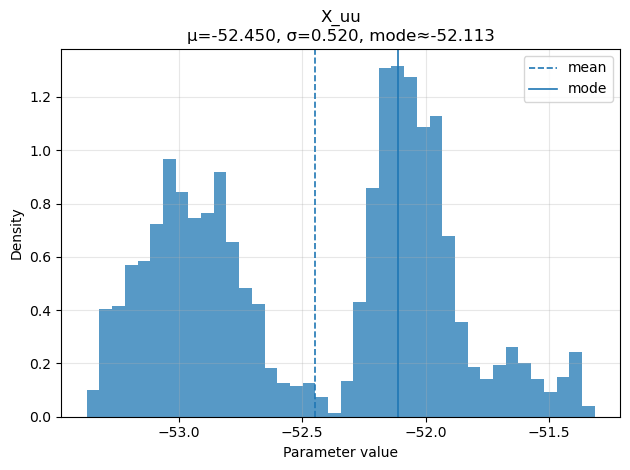

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Map DOF group -> list of parameter names to plot
# ------------------------------------------------------------
PARAM_GROUPS = {
    "X": ["X_dot_u", "X_u", "X_uu"],
    "Y": ["Y_dot_v", "Y_v", "Y_vv"],
    "Z": ["Z_dot_w", "Z_w", "Z_ww"],
    "K": ["K_dot_p", "K_p", "K_pp"],
    "M": ["M_dot_q", "M_q", "M_qq"],
    "N": ["N_dot_r", "N_r", "N_rr"],
    # Optional extras (not hydrodynamic coeffs but you might want them)
    "inertia": ["I_xx", "I_yy", "I_zz"],
    "cg": ["x_g", "y_g", "z_g"],
    "buoyancy": ["B", "z_b"],
}

# ------------------------------------------------------------
# 2) Helper: plot one parameter histogram with mean/std/mode
# ------------------------------------------------------------
def plot_param_hist(name: str, samples_tensor, param_names, post_mean, post_std, bins=40):
    if name not in param_names:
        print(f"[skip] {name} not found in param_names")
        return

    i = param_names.index(name)
    data = samples_tensor[:, i].detach().cpu().numpy()

    counts, edges, _ = plt.hist(data, bins=bins, density=True, alpha=0.75)
    m = float(post_mean[i].detach().cpu())
    s = float(post_std[i].detach().cpu())

    # mode from histogram bin with max count
    k = int(np.argmax(counts))
    mode_val = 0.5 * (edges[k] + edges[k + 1])

    plt.axvline(m, linestyle="--", linewidth=1.2, label="mean")
    plt.axvline(mode_val, linestyle="-", linewidth=1.2, label="mode")

    plt.title(f"{name}\nμ={m:.3f}, σ={s:.3f}, mode≈{mode_val:.3f}", fontsize=12)
    plt.xlabel("Parameter value")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 3) Choose a DOF group and plot all associated coefficients
# ------------------------------------------------------------
target_group = "X"  # <-- set to "X","Y","Z","K","M","N", etc.

names_to_plot = PARAM_GROUPS.get(target_group, None)
if names_to_plot is None:
    raise ValueError(f"Unknown target_group='{target_group}'. Valid keys: {list(PARAM_GROUPS.keys())}")

for pname in names_to_plot:
    plot_param_hist(
        pname,
        samples_tensor=samples_tensor,
        param_names=param_names,
        post_mean=post_mean,
        post_std=post_std,
        bins=40,
    )
